In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

titanic_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(titanic_url)

print('Dataset Shape:', titanic_df.shape)
print('\nFirst 5 Rows:')
print(titanic_df.head())

Dataset Shape: (891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [2]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = titanic_df[features]
y = titanic_df['Survived']

print('Missing Values:')
print(X.isnull().sum())


Missing Values:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


In [3]:
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, stratify=y, random_state=42
)

print('Training Set Shape:', X_train.shape)
print('Testing Set Shape:', X_test.shape)

Training Set Shape: (712, 10)
Testing Set Shape: (179, 10)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_titanic = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

print('ANN Architecture:')
ann_titanic.summary()

ANN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
ann_titanic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_titanic = ann_titanic.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

print('\nModel training complete.')

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.6573 - loss: 0.6286 - val_accuracy: 0.6993 - val_loss: 0.5959
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7821 - loss: 0.5467 - val_accuracy: 0.7622 - val_loss: 0.5402
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7873 - loss: 0.4940 - val_accuracy: 0.7832 - val_loss: 0.5006
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8120 - loss: 0.4579 - val_accuracy: 0.7902 - val_loss: 0.4741
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8155 - loss: 0.4325 - val_accuracy: 0.8182 - val_loss: 0.4558
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8260 - loss: 0.4174 - val_accuracy: 0.8112 - val_loss: 0.4493
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8348 - loss: 0.4047 - val_accuracy: 0.8112 - val_loss: 0.4427
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8348 - loss: 0.3976 - val_accuracy: 0.8112 - val_l

In [6]:
test_loss, test_accuracy = ann_titanic.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

y_pred_prob = ann_titanic.predict(X_test, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

Test Accuracy: 78.21%
Test Loss: 0.4621

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.78      0.89      0.83       110
       Survived       0.78      0.61      0.68        69

       accuracy                           0.78       179
      macro avg       0.78      0.75      0.76       179
   weighted avg       0.78      0.78      0.78       179



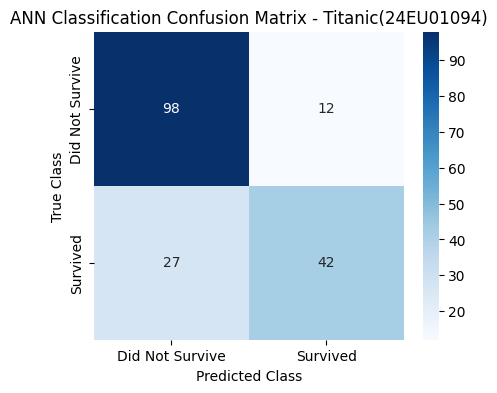

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)
plt.title('ANN Classification Confusion Matrix - Titanic(24EU01094)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

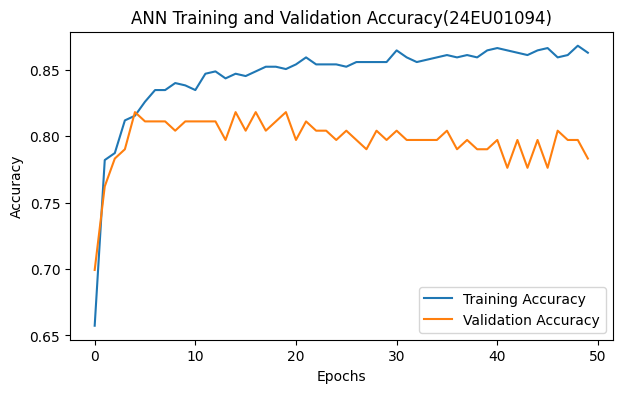

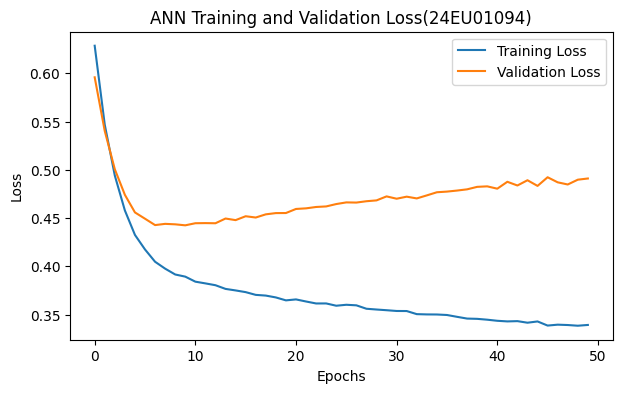

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history_titanic.history['accuracy'], label='Training Accuracy')
plt.plot(history_titanic.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ANN Training and Validation Accuracy(24EU01094)')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_titanic.history['loss'], label='Training Loss')
plt.plot(history_titanic.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ANN Training and Validation Loss(24EU01094)')
plt.legend()
plt.show()